In [1]:
import pyspark.sql.functions as F
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, MinHashLSH

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
cat_sample_path = "gs://msca-bdp-students-bucket/kireetij_final/df_cat_sample"

df_cat_sample = spark.read.parquet(cat_sample_path)

print("Loaded df_cat_sample rows:", df_cat_sample.count())
df_cat_sample.printSchema()
df_cat_sample.show(5, truncate=80)

Loaded df_cat_sample rows: 564
root
 |-- parent_asin: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- review_ts: timestamp (nullable = true)
 |-- review_date: date (nullable = true)
 |-- main_category: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- price_num: double (nullable = true)
 |-- review_id: long (nullable = true)



+-----------+----------+------------+------+--------------------------------------------------------------------------------+-------------+--------------------------------------------------------------------------------+----------------------------+-----------------+-----------------------+-----------+-------------+--------------------------------------------------------------------------------+---------+------------+
|parent_asin|      asin|helpful_vote|rating|                                                                            text|    timestamp|                                                                           title|                     user_id|verified_purchase|              review_ts|review_date|main_category|                                                                   product_title|price_num|   review_id|
+-----------+----------+------------+------+--------------------------------------------------------------------------------+-------------+-----------------

In [3]:
df_titles = df_cat_sample.select(
    "review_id",
    "parent_asin",
    F.col("title").alias("raw_title")
)

df_titles = (
    df_titles
    .filter(F.col("raw_title").isNotNull())
    .withColumn("raw_title", F.lower(F.col("raw_title")))
    .filter(F.length("raw_title") > 5)
)

print("Rows with usable titles:", df_titles.count())
df_titles.show(5, truncate=80)

regex_tokenizer_title = RegexTokenizer(
    inputCol="raw_title",
    outputCol="tokens",
    pattern="\\W+"
)

remover_title = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)

hashing_tf_title = HashingTF(
    inputCol="filtered_tokens",
    outputCol="features",
    numFeatures=2**18,
    binary=True
)

minhash_title = MinHashLSH(
    inputCol="features",
    outputCol="hashes",
    numHashTables=40
)

Rows with usable titles: 549
+------------+-----------+--------------------------------------------------------------------------------+
|   review_id|parent_asin|                                                                       raw_title|
+------------+-----------+--------------------------------------------------------------------------------+
|257698037760| 0446581348|not much for african women. quite strange for someone who talks a big game ab...|
|257698037761| 1563924285|                                                            exactly as described|
|257698037762| 1733646868|                                                           fun guide for newbies|
|257698037763| 0964680513|                                                                     no surprise|
|257698037764| 1563922088|                                                      as good as a manual can be|
+------------+-----------+--------------------------------------------------------------------------------+

In [19]:
TITLE_DISTANCE_THRESHOLD = 0.2   # ≈ Jaccard similarity >= 0.8
TARGET_N_TITLES = 15000          # keep small to protect the cluster

# 1) Features
titles_tok  = regex_tokenizer_title.transform(df_titles)
titles_tok  = remover_title.transform(titles_tok)
titles_feat = hashing_tf_title.transform(titles_tok)

# 2) Fit MinHash
mh_model_title = minhash_title.fit(titles_feat)
titles_hashed  = mh_model_title.transform(titles_feat)

# 3) Filter valid + sample
titles_lsh = (
    titles_hashed
    .filter(F.size("filtered_tokens") > 0)
    .filter(F.col("features").isNotNull())
)

total_titles = titles_lsh.count()
if total_titles > TARGET_N_TITLES:
    frac = TARGET_N_TITLES / float(total_titles)
    print(f"Sampling {TARGET_N_TITLES}/{total_titles} titles (frac={frac:.4f})")
    titles_lsh = titles_lsh.sample(False, frac, seed=42)

titles_lsh = titles_lsh.cache()
print("Final title sample size:", titles_lsh.count())

# 4) Similarity join
similar_pairs_title = mh_model_title.approxSimilarityJoin(
    titles_lsh,
    titles_lsh,
    TITLE_DISTANCE_THRESHOLD,
    distCol="JaccardDistance"
).filter(F.col("datasetA.review_id") < F.col("datasetB.review_id"))

print("Near-duplicate title pairs:", similar_pairs_title.count())
similar_pairs_title.show(10, truncate=80)

# 5) Per-title duplication counts (on sample)
dup_counts_title = (
    similar_pairs_title
    .select(F.col("datasetA.review_id").alias("review_id"))
    .union(similar_pairs_title.select(F.col("datasetB.review_id").alias("review_id")))
    .groupBy("review_id")
    .count()
    .withColumnRenamed("count", "num_title_dups")
)

title_dup_stats = (
    titles_lsh.select("review_id")
    .join(dup_counts_title, on="review_id", how="left")
    .fillna({"num_title_dups": 0})
)

title_dup_stats.orderBy(F.desc("num_title_dups")).show(10)

Final title sample size: 546
Near-duplicate title pairs: 1870
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+---------------+
|                                                                        datasetA|                                                                        datasetB|JaccardDistance|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+---------------+
|{910533066753, 0964680513, five stars, [five, stars], [five, stars], (262144,...|{962072674305, B0042EEAAG, five stars, [five, stars], [five, stars], [[7.7214...|            0.0|
|{712964571140, B00QZ2XYS2, five stars, [five, stars], [five, stars], (262144,...|{876173328384, 1563923572, five stars, [five, stars], [five, stars], [[7.7214...|            0.0|
|{154618822662, 1561588296, good book,

+-------------+--------------+
|    review_id|num_title_dups|
+-------------+--------------+
| 910533066753|            58|
| 163208757248|            58|
| 420906795012|            58|
| 712964571140|            58|
| 154618822657|            58|
| 876173328384|            58|
|1013612281857|            58|
| 420906795011|            58|
|1005022347265|            58|
| 979252543493|            58|
+-------------+--------------+
only showing top 10 rows



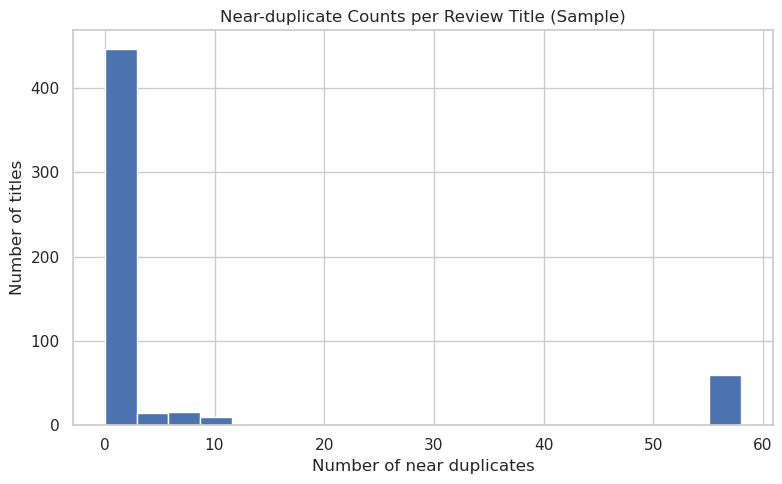

Titles in sample: 546
Titles with >=1 near-duplicate: 151 (27.66%)


In [5]:
%matplotlib inline
pdf_title_dup = title_dup_stats.toPandas()

plt.figure(figsize=(8,5))
plt.hist(pdf_title_dup["num_title_dups"], bins=20)
plt.title("Near-duplicate Counts per Review Title (Sample)")
plt.xlabel("Number of near duplicates")
plt.ylabel("Number of titles")
plt.tight_layout()
plt.show()

total = len(pdf_title_dup)
with_dups = (pdf_title_dup["num_title_dups"] > 0).sum()
print(f"Titles in sample: {total}")
print(f"Titles with >=1 near-duplicate: {with_dups} ({with_dups/total:.2%})")

In [14]:
title_dup_full = (
    titles_lsh
    .select("review_id", "parent_asin")
    .join(title_dup_stats, on="review_id", how="left")
    .fillna({"num_title_dups": 0})
)

title_dup_full.show(10)

+-----------+-----------+--------------+
|  review_id|parent_asin|num_title_dups|
+-----------+-----------+--------------+
| 8589934592| B000CMFOPW|             0|
| 8589934593| 0446581348|             0|
| 8589934594| B0042EEAAG|            58|
|17179869184| 0446581348|             0|
|34359738368| 0446581348|            58|
|34359738369| 1492640077|            58|
|34359738370| 2748033353|            58|
|34359738371| 1733646868|             0|
|34359738372| B005IQ3PS0|             0|
|77309411328| 1481839535|             0|
+-----------+-----------+--------------+
only showing top 10 rows



In [15]:
top5_products = (
    title_dup_full
    .groupBy("parent_asin")
    .agg(F.count("*").alias("n_reviews"))
    .orderBy(F.desc("n_reviews"))
    .limit(5)
)

top5_products.show(truncate=False)

top5_asins = [r["parent_asin"] for r in top5_products.collect()]
print("Top 5 parent_asin:", top5_asins)

+-----------+---------+
|parent_asin|n_reviews|
+-----------+---------+
|B0042EEAAG |79       |
|0446581348 |54       |
|1563923572 |43       |
|B005IQ3PS0 |31       |
|0892878053 |30       |
+-----------+---------+

Top 5 parent_asin: ['B0042EEAAG', '0446581348', '1563923572', 'B005IQ3PS0', '0892878053']


In [16]:
title_dup_top5 = title_dup_full.filter(F.col("parent_asin").isin(top5_asins))

title_dup_summary_top5 = (
    title_dup_top5
    .groupBy("parent_asin")
    .agg(
        F.count("*").alias("n_reviews"),
        F.sum(F.when(F.col("num_title_dups") > 0, 1).otherwise(0)).alias("n_reviews_with_dup_titles")
    )
    .withColumn("dup_fraction", F.col("n_reviews_with_dup_titles") / F.col("n_reviews"))
    .orderBy(F.desc("dup_fraction"))
)

title_dup_summary_top5.show(truncate=False)

+-----------+---------+-------------------------+-------------------+
|parent_asin|n_reviews|n_reviews_with_dup_titles|dup_fraction       |
+-----------+---------+-------------------------+-------------------+
|0446581348 |54       |18                       |0.3333333333333333 |
|0892878053 |30       |10                       |0.3333333333333333 |
|1563923572 |43       |13                       |0.3023255813953488 |
|B005IQ3PS0 |31       |8                        |0.25806451612903225|
|B0042EEAAG |79       |18                       |0.22784810126582278|
+-----------+---------+-------------------------+-------------------+



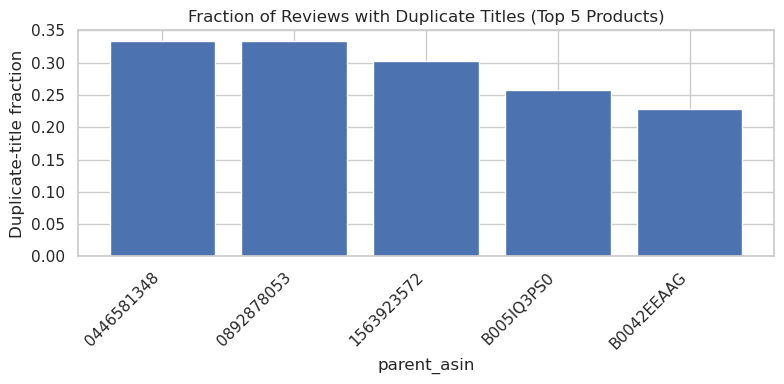

,parent_asin,n_reviews,n_reviews_with_dup_titles,dup_fraction
0,0446581348,54,18,0.333333
1,0892878053,30,10,0.333333
2,1563923572,43,13,0.302326
3,B005IQ3PS0,31,8,0.258065
4,B0042EEAAG,79,18,0.227848


In [18]:
%matplotlib inline

pdf_top5_title = title_dup_summary_top5.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(pdf_top5_title["parent_asin"], pdf_top5_title["dup_fraction"])
plt.title("Fraction of Reviews with Duplicate Titles (Top 5 Products)")
plt.xlabel("parent_asin")
plt.ylabel("Duplicate-title fraction")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

pdf_top5_title
